In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q astropy

import os, time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [45]:
DATA_DIR = '/content/drive/MyDrive/ps1'
LABELS_PATH         = f'{DATA_DIR}/labels.fits'
TRAIN_FEATURES_PATH = f'{DATA_DIR}/train_features.npy'
VALID_FEATURES_PATH = f'{DATA_DIR}/valid_features.npy'
TEST_FEATURES_PATH  = f'{DATA_DIR}/test_features.npy'

In [46]:
X_train = np.load(TRAIN_FEATURES_PATH).astype(np.float32)
X_val   = np.load(VALID_FEATURES_PATH).astype(np.float32)
X_test  = np.load(TEST_FEATURES_PATH).astype(np.float32)
print('feature shapes:', X_train.shape, X_val.shape, X_test.shape)


feature shapes: (1024, 8575) (256, 8575) (512, 8575)


In [47]:
# Load labels
allstar = fits.open(LABELS_PATH)
labels  = allstar[1].data

RGB = np.ones(len(labels), dtype=bool)
RGB &= labels['TEFF'] > 3500.
RGB &= labels['TEFF'] < 5400.
RGB &= labels['LOGG'] < 3.0
RGB &= labels['LOGG'] > 0.0
RGB &= labels['H']    < 10.5
print(f'RGB sample size: {RGB.sum()}')

RGB_labels = labels[RGB]

rng = np.random.default_rng(17)
N_RGB = len(RGB_labels)
N_train, N_valid, N_test = 1024, 256, 512
I = rng.permutation(N_RGB)
I_train = I[0:N_train]
I_valid = I[N_train:N_train+N_valid]
I_test  = I[N_train+N_valid:N_train+N_valid+N_test]

train_labels = RGB_labels[I_train]
valid_labels = RGB_labels[I_valid]
test_labels  = RGB_labels[I_test]
print('label table sizes:', len(train_labels), len(valid_labels), len(test_labels))

LABEL_NAME = 'LOGG'
y_train = np.asarray(train_labels[LABEL_NAME], dtype=np.float32)
y_val   = np.asarray(valid_labels[LABEL_NAME], dtype=np.float32)
y_test  = np.asarray(test_labels[LABEL_NAME],  dtype=np.float32)

# Sanity check that feature counts match label counts
assert X_train.shape[0] == y_train.shape[0], (X_train.shape, y_train.shape)
assert X_val.shape[0]   == y_val.shape[0]
assert X_test.shape[0]  == y_test.shape[0]
print('y ranges: train [%.2f, %.2f]  val [%.2f, %.2f]  test [%.2f, %.2f]'
      % (y_train.min(), y_train.max(), y_val.min(), y_val.max(),
         y_test.min(),  y_test.max()))

RGB sample size: 145991
label table sizes: 1024 256 512
y ranges: train [0.11, 3.00]  val [0.28, 3.00]  test [0.21, 3.00]


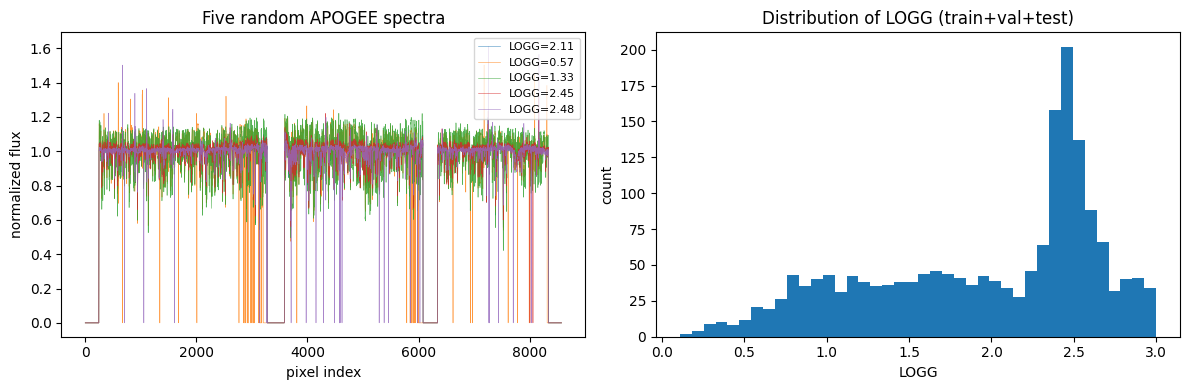

In [48]:
rng_plot = np.random.default_rng(0)
idx = rng_plot.choice(len(X_train), 5, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in idx:
    axes[0].plot(X_train[i], lw=0.4, alpha=0.8, label=f'LOGG={y_train[i]:.2f}')
axes[0].set_xlabel('pixel index'); axes[0].set_ylabel('normalized flux')
axes[0].set_title('Five random APOGEE spectra'); axes[0].legend(fontsize=8)

axes[1].hist(np.concatenate([y_train, y_val, y_test]), bins=40)
axes[1].set_xlabel(LABEL_NAME); axes[1].set_ylabel('count')
axes[1].set_title(f'Distribution of {LABEL_NAME} (train+val+test)')
plt.tight_layout(); plt.show()


In [49]:
X_train = np.where(np.isfinite(X_train), X_train, 0.0).astype(np.float32)
X_val   = np.where(np.isfinite(X_val),   X_val,   0.0).astype(np.float32)
X_test  = np.where(np.isfinite(X_test),  X_test,  0.0).astype(np.float32)

In [50]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

y_mean, y_std = float(y_train.mean()), float(y_train.std())
def normy(a):  return (a - y_mean) / y_std
def denorm(a): return a * y_std + y_mean
print(f'y_mean={y_mean:.3f}  y_std={y_std:.3f}')


y_mean=1.934  y_std=0.705


In [51]:
def evaluate(name, y_true, y_pred, store=None):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f'{name:>34s}   RMSE={rmse:.3f}   MAE={mae:.3f}   R^2={r2:.3f}')
    if store is not None:
        store[name] = {'rmse': rmse, 'mae': mae, 'r2': r2}
    return rmse, mae, r2

def parity_plot(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_true, y_pred, s=8, alpha=0.5)
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel(f'true {LABEL_NAME}')
    ax.set_ylabel(f'predicted {LABEL_NAME}')
    ax.set_title(title); ax.set_aspect('equal'); plt.show()

results = {}


In [52]:
# Plain OLS for reference
ols = LinearRegression().fit(X_train_s, y_train)
evaluate('Linear (val)', y_val, ols.predict(X_val_s))

# Ridge sweep
ridge_alphas = [1e-2, 1e-1, 1.0, 10.0, 100.0, 1e3]
ridge_val_rmse = []
for a in ridge_alphas:
    m = Ridge(alpha=a).fit(X_train_s, y_train)
    rmse, _, _ = evaluate(f'Ridge alpha={a:<6g} (val)', y_val, m.predict(X_val_s))
    ridge_val_rmse.append(rmse)

best_alpha = ridge_alphas[int(np.argmin(ridge_val_rmse))]
print(f'\nBest Ridge alpha by val RMSE: {best_alpha}')


                      Linear (val)   RMSE=0.400   MAE=0.240   R^2=0.645


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.45425e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


          Ridge alpha=0.01   (val)   RMSE=0.400   MAE=0.240   R^2=0.645


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.62011e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


          Ridge alpha=0.1    (val)   RMSE=0.400   MAE=0.240   R^2=0.647
          Ridge alpha=1      (val)   RMSE=0.394   MAE=0.236   R^2=0.657
          Ridge alpha=10     (val)   RMSE=0.359   MAE=0.212   R^2=0.715
          Ridge alpha=100    (val)   RMSE=0.281   MAE=0.169   R^2=0.826
          Ridge alpha=1000   (val)   RMSE=0.233   MAE=0.155   R^2=0.880

Best Ridge alpha by val RMSE: 1000.0


          Ridge alpha=1000.0 (val)   RMSE=0.233   MAE=0.155   R^2=0.880


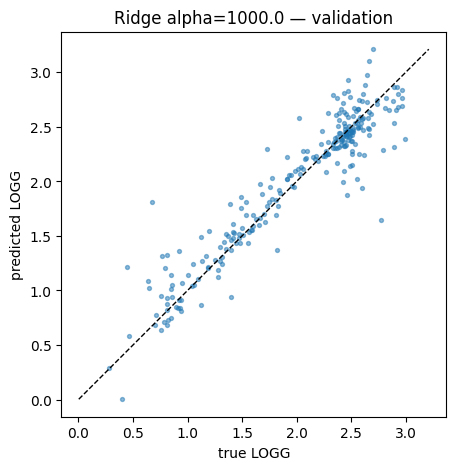

In [53]:
# Final ridge at best alpha
ridge = Ridge(alpha=best_alpha).fit(X_train_s, y_train)
evaluate(f'Ridge alpha={best_alpha} (val)', y_val, ridge.predict(X_val_s), store=results)
parity_plot(y_val, ridge.predict(X_val_s), f'Ridge alpha={best_alpha} — validation')


### K-NN

k=  1   val RMSE=0.259
k=  3   val RMSE=0.241
k=  5   val RMSE=0.228
k= 10   val RMSE=0.234
k= 25   val RMSE=0.261
k= 50   val RMSE=0.290
k=100   val RMSE=0.327


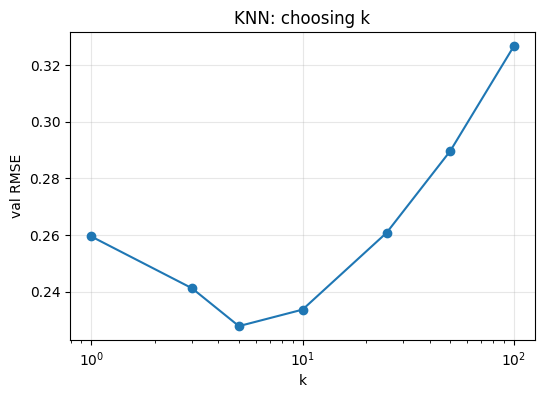


Best k by val RMSE: 5


In [54]:
ks = [1, 3, 5, 10, 25, 50, 100]
val_rmse_k = []
for k in ks:
    m = KNeighborsRegressor(n_neighbors=k, weights='distance', n_jobs=-1).fit(X_train_s, y_train)
    rmse = float(np.sqrt(mean_squared_error(y_val, m.predict(X_val_s))))
    val_rmse_k.append(rmse)
    print(f'k={k:3d}   val RMSE={rmse:.3f}')

plt.figure(figsize=(6, 4))
plt.plot(ks, val_rmse_k, 'o-')
plt.xscale('log'); plt.xlabel('k'); plt.ylabel('val RMSE')
plt.title('KNN: choosing k'); plt.grid(True, alpha=0.3); plt.show()

best_k = ks[int(np.argmin(val_rmse_k))]
print(f'\nBest k by val RMSE: {best_k}')


                     KNN k=5 (val)   RMSE=0.228   MAE=0.152   R^2=0.885


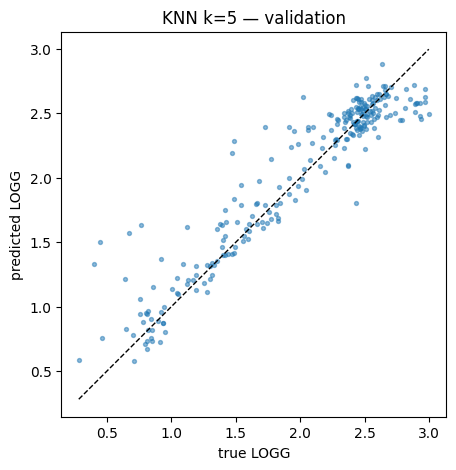

In [55]:
knn = KNeighborsRegressor(n_neighbors=best_k, weights='distance', n_jobs=-1).fit(X_train_s, y_train)
evaluate(f'KNN k={best_k} (val)', y_val, knn.predict(X_val_s), store=results)
parity_plot(y_val, knn.predict(X_val_s), f'KNN k={best_k} — validation')


In [56]:
# KNN seed-stability: shuffle the train+val pool, redo the split, refit.
# Test set is held out and untouched.
X_tv_raw = np.vstack([X_train, X_val])
y_tv_raw = np.concatenate([y_train, y_val])

knn_seed_rmse = []
for s in [0, 1, 2, 3, 4]:
    rng_s = np.random.default_rng(s)
    perm  = rng_s.permutation(len(X_tv_raw))
    n_tr  = len(X_train)
    Xtr, Xv = X_tv_raw[perm[:n_tr]], X_tv_raw[perm[n_tr:]]
    ytr, yv = y_tv_raw[perm[:n_tr]], y_tv_raw[perm[n_tr:]]
    sc = StandardScaler().fit(Xtr)
    m  = KNeighborsRegressor(n_neighbors=best_k, weights='distance', n_jobs=-1)
    m.fit(sc.transform(Xtr), ytr)
    rmse = float(np.sqrt(mean_squared_error(yv, m.predict(sc.transform(Xv)))))
    knn_seed_rmse.append(rmse)
    print(f'seed={s}   val RMSE={rmse:.3f}')
print(f'\nKNN seed RMSE: mean={np.mean(knn_seed_rmse):.3f}, std={np.std(knn_seed_rmse):.3f}')


seed=0   val RMSE=0.194
seed=1   val RMSE=0.249
seed=2   val RMSE=0.207
seed=3   val RMSE=0.211
seed=4   val RMSE=0.223

KNN seed RMSE: mean=0.217, std=0.019


### Multi-Layer

In [57]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(512, 256, 128), p_drop=0.1):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.LayerNorm(h),
                       nn.LeakyReLU(0.1), nn.Dropout(p_drop)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, a=0.1, nonlinearity='leaky_relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(X_tr, y_tr, X_va, y_va,
              hidden=(512, 256, 128), lr=1e-3, weight_decay=1e-4,
              epochs=60, batch_size=128, p_drop=0.1, seed=0,
              clip=5.0, verbose=False):
    torch.manual_seed(seed); np.random.seed(seed)

    Xtr = torch.tensor(X_tr, dtype=torch.float32, device=device)
    ytr = torch.tensor(normy(y_tr), dtype=torch.float32, device=device)
    Xva = torch.tensor(X_va, dtype=torch.float32, device=device)
    yva = torch.tensor(normy(y_va), dtype=torch.float32, device=device)

    model = MLP(Xtr.shape[1], hidden=hidden, p_drop=p_drop).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.MSELoss()

    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    train_hist, val_hist = [], []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            running += loss.item() * len(xb)
        sched.step()
        running /= len(Xtr)
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xva), yva).item()
        train_hist.append(running); val_hist.append(val_loss)
        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f'  epoch {epoch:3d}   train MSE={running:.4f}   val MSE={val_loss:.4f}')
    return model, train_hist, val_hist


def predict(model, X_s):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X_s, dtype=torch.float32, device=device)).cpu().numpy()
    return denorm(out)


  epoch   0   train MSE=1.9145   val MSE=0.2120
  epoch  10   train MSE=0.0539   val MSE=0.0845
  epoch  20   train MSE=0.0273   val MSE=0.0781
  epoch  30   train MSE=0.0187   val MSE=0.0752
  epoch  40   train MSE=0.0155   val MSE=0.0704
  epoch  50   train MSE=0.0139   val MSE=0.0702
  epoch  59   train MSE=0.0143   val MSE=0.0696


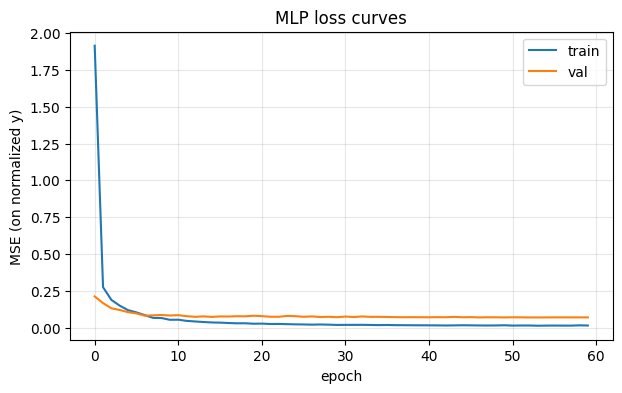

                MLP baseline (val)   RMSE=0.186   MAE=0.129   R^2=0.924


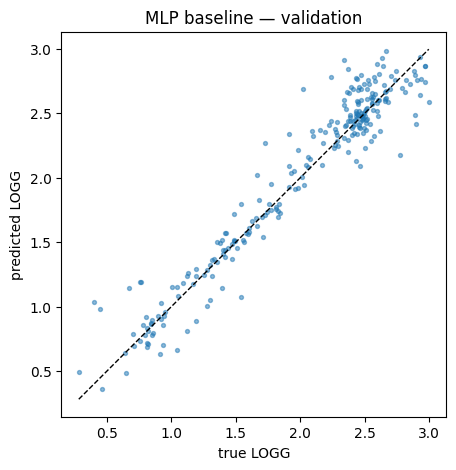

In [36]:
# Baseline MLP
model, th, vh = train_mlp(
    X_train_s, y_train, X_val_s, y_val,
    hidden=(512, 256, 128), lr=1e-3, p_drop=0.1, epochs=60, seed=0, verbose=True
)

plt.figure(figsize=(7, 4))
plt.plot(th, label='train'); plt.plot(vh, label='val')
plt.xlabel('epoch'); plt.ylabel('MSE (on normalized y)')
plt.title('MLP loss curves'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

y_val_pred = predict(model, X_val_s)
evaluate('MLP baseline (val)', y_val, y_val_pred, store=results)
parity_plot(y_val, y_val_pred, 'MLP baseline — validation')


### Hyperparameter tuning

In [37]:
configs = [
    dict(hidden=(256, 128),         lr=1e-3, p_drop=0.1, epochs=60),
    dict(hidden=(512, 256, 128),    lr=1e-3, p_drop=0.1, epochs=60),
    dict(hidden=(1024, 512, 256),   lr=5e-4, p_drop=0.2, epochs=60),
    dict(hidden=(512, 256, 128),    lr=3e-3, p_drop=0.1, epochs=60),
    dict(hidden=(512, 256, 128),    lr=1e-4, p_drop=0.0, epochs=60),
    dict(hidden=(512, 256, 128),    lr=1e-3, p_drop=0.3, epochs=60),
]
hp_results = []
for cfg in configs:
    t0 = time.time()
    m, _, _ = train_mlp(X_train_s, y_train, X_val_s, y_val, seed=0, **cfg)
    pred = predict(m, X_val_s)
    rmse = float(np.sqrt(mean_squared_error(y_val, pred)))
    hp_results.append((cfg, rmse))
    print(f'{cfg}  ->  val RMSE={rmse:.3f}  ({time.time()-t0:.1f}s)')

best_cfg = min(hp_results, key=lambda r: r[1])[0]
print('\nBest MLP config:', best_cfg)


{'hidden': (256, 128), 'lr': 0.001, 'p_drop': 0.1, 'epochs': 60}  ->  val RMSE=0.195  (1.8s)
{'hidden': (512, 256, 128), 'lr': 0.001, 'p_drop': 0.1, 'epochs': 60}  ->  val RMSE=0.186  (2.4s)
{'hidden': (1024, 512, 256), 'lr': 0.0005, 'p_drop': 0.2, 'epochs': 60}  ->  val RMSE=0.181  (3.4s)
{'hidden': (512, 256, 128), 'lr': 0.003, 'p_drop': 0.1, 'epochs': 60}  ->  val RMSE=0.184  (2.6s)
{'hidden': (512, 256, 128), 'lr': 0.0001, 'p_drop': 0.0, 'epochs': 60}  ->  val RMSE=0.271  (2.9s)
{'hidden': (512, 256, 128), 'lr': 0.001, 'p_drop': 0.3, 'epochs': 60}  ->  val RMSE=0.185  (2.4s)

Best MLP config: {'hidden': (1024, 512, 256), 'lr': 0.0005, 'p_drop': 0.2, 'epochs': 60}


In [38]:
# Seed stability for the chosen MLP config
mlp_seed_rmse = []
for s in [0, 1, 2, 3, 4]:
    m, _, _ = train_mlp(X_train_s, y_train, X_val_s, y_val, seed=s, **best_cfg)
    rmse = float(np.sqrt(mean_squared_error(y_val, predict(m, X_val_s))))
    mlp_seed_rmse.append(rmse)
    print(f'seed={s}   val RMSE={rmse:.3f}')
print(f'\nMLP seed RMSE: mean={np.mean(mlp_seed_rmse):.3f}, std={np.std(mlp_seed_rmse):.3f}')


seed=0   val RMSE=0.181
seed=1   val RMSE=0.180
seed=2   val RMSE=0.173
seed=3   val RMSE=0.180
seed=4   val RMSE=0.181

MLP seed RMSE: mean=0.179, std=0.003


In [39]:
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])
scaler_tv = StandardScaler().fit(X_tv)
X_tv_s    = scaler_tv.transform(X_tv).astype(np.float32)
X_test_s2 = scaler_tv.transform(X_test).astype(np.float32)

# update target stats on the larger set (used by the MLP normalizer)
y_mean = float(y_tv.mean()); y_std = float(y_tv.std())

test_results = {}

# Ridge
ridge_final = Ridge(alpha=best_alpha).fit(X_tv_s, y_tv)
evaluate(f'Ridge alpha={best_alpha} (TEST)', y_test,
         ridge_final.predict(X_test_s2), store=test_results)

# KNN
knn_final = KNeighborsRegressor(n_neighbors=best_k, weights='distance', n_jobs=-1)
knn_final.fit(X_tv_s, y_tv)
evaluate(f'KNN k={best_k} (TEST)', y_test,
         knn_final.predict(X_test_s2), store=test_results)

# MLP — average over seeds for a more honest test number
mlp_test_preds = []
for s in [0, 1, 2, 3, 4]:
    m, _, _ = train_mlp(X_tv_s, y_tv, X_test_s2, y_test, seed=s, **best_cfg)
    mlp_test_preds.append(predict(m, X_test_s2))
mlp_test_pred = np.mean(mlp_test_preds, axis=0)
evaluate('MLP ensemble-of-5-seeds (TEST)', y_test, mlp_test_pred, store=test_results)
# also keep a single-seed version for the parity plot
mlp_final_pred = mlp_test_preds[0]


         Ridge alpha=1000.0 (TEST)   RMSE=0.209   MAE=0.142   R^2=0.905
                    KNN k=5 (TEST)   RMSE=0.220   MAE=0.153   R^2=0.895
    MLP ensemble-of-5-seeds (TEST)   RMSE=0.174   MAE=0.116   R^2=0.935


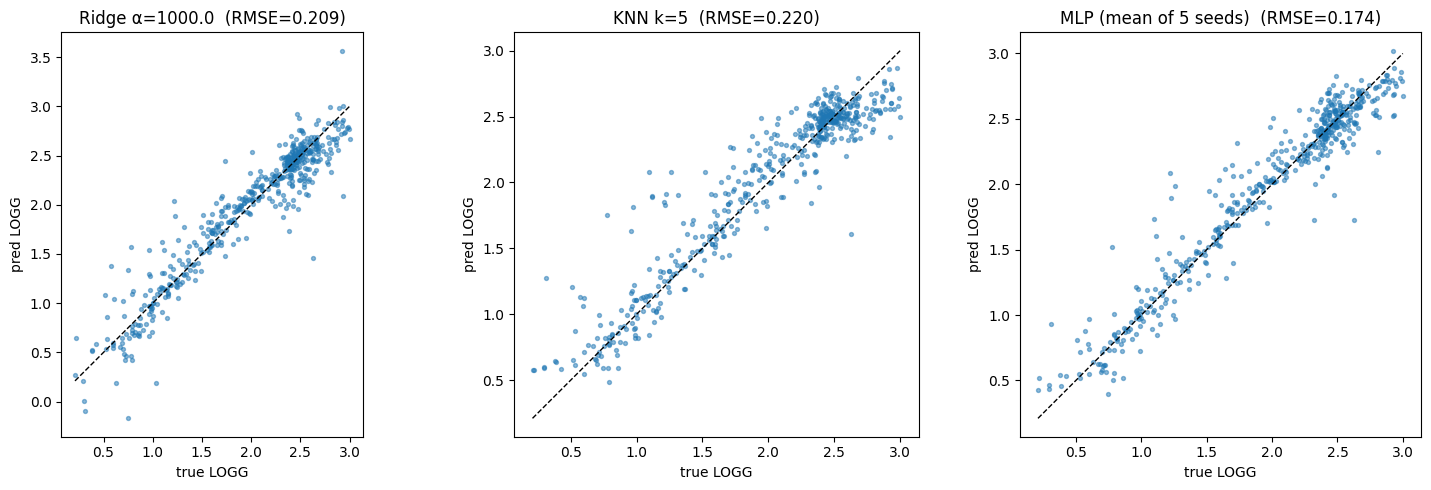

In [40]:
# Side-by-side parity plots on the test set
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
preds_named = [
    (f'Ridge α={best_alpha}',  ridge_final.predict(X_test_s2)),
    (f'KNN k={best_k}',        knn_final.predict(X_test_s2)),
    ('MLP (mean of 5 seeds)',  mlp_test_pred),
]
for ax, (name, pred) in zip(axes, preds_named):
    ax.scatter(y_test, pred, s=8, alpha=0.5)
    lim = [float(y_test.min()), float(y_test.max())]
    ax.plot(lim, lim, 'k--', lw=1)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    ax.set_title(f'{name}  (RMSE={rmse:.3f})')
    ax.set_xlabel(f'true {LABEL_NAME}'); ax.set_ylabel(f'pred {LABEL_NAME}')
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()


In [41]:
print('Final TEST-set summary')
print('='*60)
for name, m in test_results.items():
    print(f'{name:>40s}   RMSE={m["rmse"]:.3f}   MAE={m["mae"]:.3f}   R²={m["r2"]:.3f}')


Final TEST-set summary
               Ridge alpha=1000.0 (TEST)   RMSE=0.209   MAE=0.142   R²=0.905
                          KNN k=5 (TEST)   RMSE=0.220   MAE=0.153   R²=0.895
          MLP ensemble-of-5-seeds (TEST)   RMSE=0.174   MAE=0.116   R²=0.935


with the assistance of Google's Gemini AI (2026 version).


## Final project
Symmetry-Aware Neural Networks for Phase Retrieval of Nonlinear Susceptibility Tensors

Rotational Anisotropy Second Harmonic Generation (RA-SHG) is a highly sensitive optical technique used to probe crystallographic symmetry, but extracting the underlying nonlinear susceptibility tensor ($\chi^{(2)}$) from intensity patterns is a complex, ill-posed inverse problem. Traditional least-squares fitting methods are computationally expensive and vulnerable to phase-retrieval degeneracies introduced by experimental noise and azimuthal misalignment.
We aim to develop a physics-informed deep learning framework capable of robust, high-throughput phase retrieval of nonlinear susceptibility tensors directly from RA-SHG data.